# **One-Slit Experiment**

#### *(1) Experimental Data*

In [5]:
# (0) Import our dataframe
import pandas as pd
import numpy as np
df = pd.read_csv("Data\single_slit_experiment_real_data.csv")
df.head(5)

,Date and Time Run 2,Time (s) Run 2,Position (mm) Run 2,Light Intensity (%) Run 2,Log of Light Intensity Run 2
0,4/13/2025 20:42,0.00,0.0,6.0,2.8
1,4/13/2025 20:42,0.05,0.0,6.0,2.8
2,4/13/2025 20:42,0.10,0.0,6.0,2.8
3,4/13/2025 20:42,0.15,0.0,6.0,2.8
4,4/13/2025 20:42,0.20,0.0,6.0,2.8


In [10]:
# (1) Recenter the graph
x_coords = list(df[df.columns[2]])
y_coords = list(df[df.columns[3]])

# (1.1) Find where the maximum intensity occurs and recenter the graph accordingly
intensity_max = max(y_coords)
center_index = y_coords.index(intensity_max)
x_center = x_coords[center_index]

x_coords = [x - x_center for x in x_coords]
print("Max intensity:", intensity_max)
print("Center of interference pattern:", x_center)

# (1.2) Scale our intensity pattern to 100%, and make sure 0 is 0
y_coords = [y * (100/intensity_max) for y in y_coords]
minimum = np.average(y_coords[-50:])
print(minimum)
y_coords = [y - minimum for y in y_coords]


Max intensity: 6.3
Center of interference pattern: 0.0
6.444444444444444


In [11]:
x_coords_measured_data = x_coords
y_coords_measured_data = y_coords

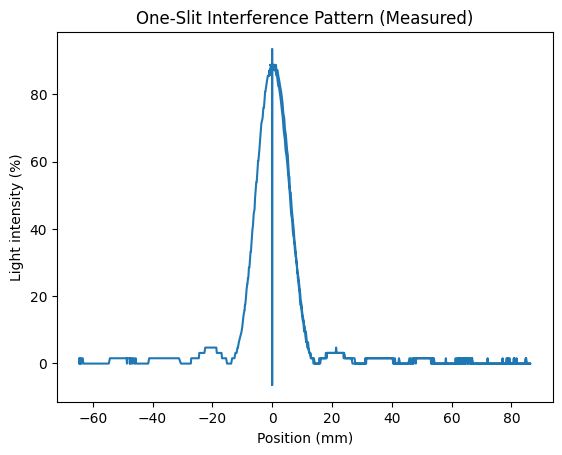

In [12]:
# (2) Plot our data in matplotlib
import matplotlib.pyplot as plt
plt.plot(x_coords_measured_data, y_coords_measured_data)
plt.xlabel("Position (mm)")
plt.ylabel("Light intensity (%)")
plt.title("One-Slit Interference Pattern (Measured)")
plt.show()

#### *(2) Ensemble Equation Data*

In [13]:
# (0) Import our dataframe
import pandas as pd
df = pd.read_csv("Data\single_slit_experiment_ensemble_equation.csv")
df.head(5)

,-16,0
0,-15.96875,0.0
1,-15.93750,0.0
2,-15.90625,0.0
3,-15.87500,0.0
4,-15.84375,0.0


In [14]:
# (1) Rescale our distribution and square it to get the intensity
import matplotlib.pyplot as plt
x_coords = list(df[df.columns[0]])
y_coords = list(df[df.columns[1]])

# (1.1) To get the correct scale in mm for our equation, we need to multiply by .0825
s = 5   # Actual distance of center of slits from the mean
x_coords = [x * s  for x in x_coords]

# (1.2) Scale our intensity pattern to 100%
intensity_max = max(y_coords)
y_coords = [y * (100/intensity_max) for y in y_coords]

# (1.3) Finally since the intensity is proportional to the square of the distribution (Born's Rule)
y_coords = [y**2 / 100 for y in y_coords]


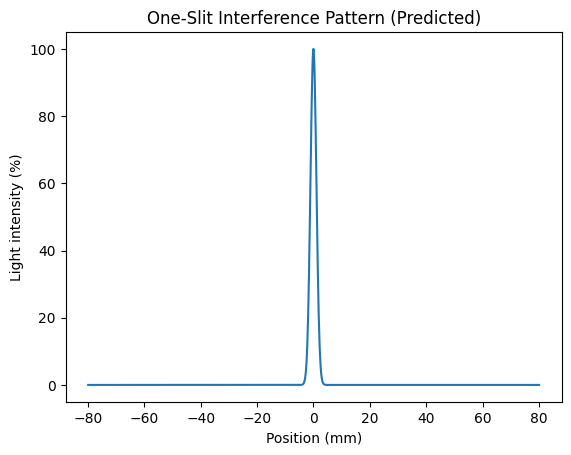

In [15]:
# (2) Plot these graphs
plt.plot(x_coords, y_coords)
plt.xlabel("Position (mm)")
plt.ylabel("Light intensity (%)")
plt.title("One-Slit Interference Pattern (Predicted)")
plt.show()

#### *(3) Sythesize*

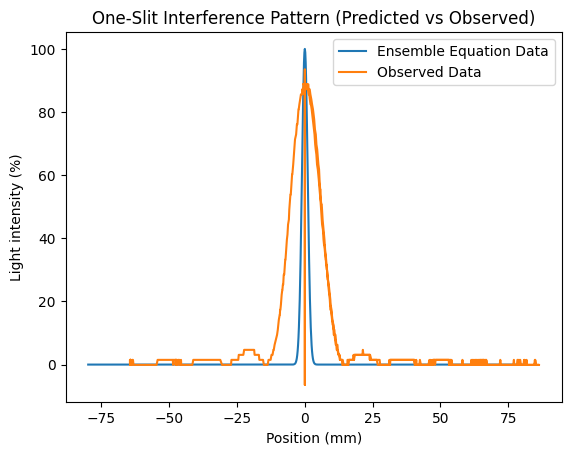

In [17]:
# (0) Create two line plots
plt.plot(x_coords, y_coords, label='Ensemble Equation Data')
plt.plot(x_coords_measured_data, y_coords_measured_data, label='Observed Data')
plt.xlabel("Position (mm)")
plt.ylabel("Light intensity (%)")
plt.title("One-Slit Interference Pattern (Predicted vs Observed)")
plt.legend()
plt.show()